# PAPA and SOTS CTD Profile Analysis
The objective for this notebook was to provide an oceanographic context for the study location, as well as the Northern-hemisphere comparison point of PAPA ocean station. This assists the flux analysis and a quick method to view decadal upper-ocean structure.

In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
os.getcwd()

'/home/581/ob1561'

In [3]:
os.chdir("/g/data/jk72/ob1561/Ship_data_PAPA")
os.getcwd()

'/g/data/jk72/ob1561/Ship_data_PAPA'

## Browse directory and filenames

In [4]:
data_dir = "/g/data/jk72/ob1561/Ship_data_PAPA"
files = sorted(glob.glob(data_dir + "/*_ctd.nc"))

len(files), files[:3], files[-3:]

(10,
 ['/g/data/jk72/ob1561/Ship_data_PAPA/18DD20100817_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/18DD20110816_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/18DD20120814_ctd.nc'],
 ['/g/data/jk72/ob1561/Ship_data_PAPA/18DD20170815_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/18DD20180911_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/18DD20190813_ctd.nc'])

In [5]:
ds = xr.open_dataset("/g/data/jk72/ob1561/Ship_data_PAPA/18DD20100817_ctd.nc")
list(ds.data_vars)

['event_number',
 'pressure_qc',
 'ctd_temperature',
 'ctd_temperature_qc',
 'ctd_salinity',
 'ctd_salinity_qc',
 'ctd_oxygen',
 'ctd_oxygen_qc',
 'ctd_fluor',
 'ctd_fluor_qc',
 'par',
 'par_qc',
 'ctd_beamcp',
 'ctd_beamcp_qc',
 'profile_type',
 'geometry_container']

## Quick plot to look at general PAPA data

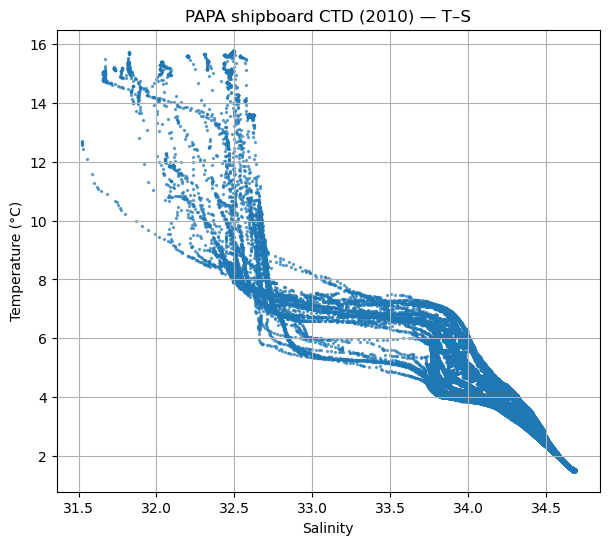

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

f0 = "/g/data/jk72/ob1561/Ship_data_PAPA/18DD20100817_ctd.nc"
ds = xr.open_dataset(f0)

T = ds["ctd_temperature"].astype("float64")
S = ds["ctd_salinity"].astype("float64")
P = ds["pressure"].astype("float64")

Tqc = ds["ctd_temperature_qc"]
Sqc = ds["ctd_salinity_qc"]
Pqc = ds["pressure_qc"]

# Common CCHDO convention: 2=good, 1=probably good; treat 1/2 as usable
good = np.isin(Tqc, [1, 2]) & np.isin(Sqc, [1, 2]) & np.isin(Pqc, [1, 2])

t = T.where(good).values.ravel()
s = S.where(good).values.ravel()
p = P.where(good).values.ravel()

m = np.isfinite(t) & np.isfinite(s)
t, s, p = t[m], s[m], p[m]

plt.figure(figsize=(7,6))
plt.scatter(s, t, s=2, alpha=0.6)
plt.xlabel("Salinity")
plt.ylabel("Temperature (°C)")
plt.title("PAPA shipboard CTD (2010) — T–S")
plt.grid(True)
plt.show()


## Function cell to identify useable vs unusable data, inconcistencies and data variable names (important with ship cast data)

In [7]:
import xarray as xr
import numpy as np
import pandas as pd

f0 = "/g/data/jk72/ob1561/Ship_data_PAPA/18DD20100817_ctd.nc"
ds = xr.open_dataset(f0)

# ---- Helper: safe summary stats
def summarize_array(da, name, mask=None):
    x = da.values
    if mask is not None:
        x = np.where(mask, x, np.nan)
    x = x.astype("float64").ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"var": name, "n": 0, "min": np.nan, "p05": np.nan, "median": np.nan, "p95": np.nan, "max": np.nan}
    return {
        "var": name,
        "n": int(x.size),
        "min": float(np.nanmin(x)),
        "p05": float(np.nanpercentile(x, 5)),
        "median": float(np.nanmedian(x)),
        "p95": float(np.nanpercentile(x, 95)),
        "max": float(np.nanmax(x)),
    }

# ---- Core variables (confirmed from your file)
T = ds["ctd_temperature"]
S = ds["ctd_salinity"]
P = ds["pressure"]

Tqc = ds["ctd_temperature_qc"]
Sqc = ds["ctd_salinity_qc"]
Pqc = ds["pressure_qc"]

# CCHDO QC: treat 1=probably good, 2=good as usable (common practice)
good_T = np.isin(Tqc.values, [1, 2])
good_S = np.isin(Sqc.values, [1, 2])
good_P = np.isin(Pqc.values, [1, 2])
good_all = good_T & good_S & good_P

# ---- Dataset overview (metadata + structure)
print("=== Dataset overview ===")
print("File:", f0)
print("Dimensions:", dict(ds.dims))
print("Coordinates:", list(ds.coords))
print("Data variables (count={}):".format(len(ds.data_vars)))
print(list(ds.data_vars))
print()

# Global attributes (useful for supervisor context)
print("=== Global attributes (selected) ===")
for k in ["title", "summary", "institution", "source", "references", "history", "comment", "Conventions"]:
    if k in ds.attrs:
        val = ds.attrs[k]
        if isinstance(val, str) and len(val) > 300:
            val = val[:300] + "..."
        print(f"{k}: {val}")
print()

# ---- Identify likely profile/cast dimension name(s)
dims = list(ds.dims)
profile_dims = [d for d in dims if any(key in d.lower() for key in ["prof", "profile", "station", "cast", "event"])]
print("=== Likely profile/cast dimensions ===")
print(profile_dims if profile_dims else "(None detected; using dataset dims above)")
print()

# ---- QC pass rates
def qc_pass_rate(mask):
    return 100.0 * np.sum(mask) / mask.size

print("=== QC pass rates (1 or 2 accepted) ===")
print(f"Temperature QC pass: {qc_pass_rate(good_T):.2f}%")
print(f"Salinity QC pass:    {qc_pass_rate(good_S):.2f}%")
print(f"Pressure QC pass:    {qc_pass_rate(good_P):.2f}%")
print(f"All three pass:      {qc_pass_rate(good_all):.2f}%")
print()

# ---- Units check
print("=== Units ===")
print("ctd_temperature units:", T.attrs.get("units", "(missing)"))
print("ctd_salinity units:   ", S.attrs.get("units", "(missing)"))
print("pressure units:       ", P.attrs.get("units", "(missing)"))
print()

# ---- QC-screened physical ranges
rows = []
rows.append(summarize_array(T, "ctd_temperature (QC-screened)", mask=good_all))
rows.append(summarize_array(S, "ctd_salinity (QC-screened)", mask=good_all))
rows.append(summarize_array(P, "pressure (QC-screened)", mask=good_all))

summary_df = pd.DataFrame(rows)
print("=== QC-screened summary statistics ===")
display(summary_df)

# ---- Simple plausibility flags
tmin, tmax = summary_df.loc[summary_df["var"].str.contains("temperature"), ["min","max"]].values[0]
smin, smax = summary_df.loc[summary_df["var"].str.contains("salinity"), ["min","max"]].values[0]
pmin, pmax = summary_df.loc[summary_df["var"].str.contains("pressure"), ["min","max"]].values[0]

print("\n=== Plausibility checks (broad, ocean-wide) ===")
print("Temperature plausible (-3 to 40 °C):", (-3 <= tmin <= 40) and (-3 <= tmax <= 40))
print("Salinity plausible (0 to 42):        ", (0 <= smin <= 42) and (0 <= smax <= 42))
print("Pressure plausible (0 to 12000 dbar):", (0 <= pmin <= 12000) and (0 <= pmax <= 12000))

# ---- Optional: show how many unique events/casts exist if event_number exists
if "event_number" in ds:
    ev = ds["event_number"].values.ravel()
    ev = ev[np.isfinite(ev)] if np.issubdtype(ev.dtype, np.number) else ev
    try:
        n_unique = len(np.unique(ev))
        print(f"\nUnique event_number values (approx. cast/station count): {n_unique}")
    except Exception:
        print("\nCould not compute unique event_number count (non-standard type).")


=== Dataset overview ===
File: /g/data/jk72/ob1561/Ship_data_PAPA/18DD20100817_ctd.nc
Dimensions: {'N_PROF': 57, 'N_LEVELS': 4315}
Coordinates: ['expocode', 'station', 'cast', 'sample', 'time', 'latitude', 'longitude', 'pressure']
Data variables (count=16):
['event_number', 'pressure_qc', 'ctd_temperature', 'ctd_temperature_qc', 'ctd_salinity', 'ctd_salinity_qc', 'ctd_oxygen', 'ctd_oxygen_qc', 'ctd_fluor', 'ctd_fluor_qc', 'par', 'par_qc', 'ctd_beamcp', 'ctd_beamcp_qc', 'profile_type', 'geometry_container']

=== Global attributes (selected) ===
Conventions: CF-1.8 CCHDO-1.0

=== Likely profile/cast dimensions ===
['N_PROF']

=== QC pass rates (1 or 2 accepted) ===
Temperature QC pass: 33.39%
Salinity QC pass:    33.28%
Pressure QC pass:    33.39%
All three pass:      33.28%

=== Units ===
ctd_temperature units: degC
ctd_salinity units:    1
pressure units:        dbar

=== QC-screened summary statistics ===


/jobfs/159341261.gadi-pbs/ipykernel_559289/719508781.py:45: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensions:", dict(ds.dims))


,var,n,min,p05,median,p95,max
0,ctd_temperature (QC-screened),81865,1.4974,1.58870,3.0943,7.44958,15.7750
1,ctd_salinity (QC-screened),81865,31.5204,32.72662,34.3734,34.65450,34.6846
2,pressure (QC-screened),81865,1.3000,78.00000,1006.0000,3033.00000,4318.7000



=== Plausibility checks (broad, ocean-wide) ===
Temperature plausible (-3 to 40 °C): True
Salinity plausible (0 to 42):         True
Pressure plausible (0 to 12000 dbar): True

Unique event_number values (approx. cast/station count): 57


## Summary tables to see general cast pattern and variable names. As well as pressure ticks (before I bin it in 10dbar increments)

In [8]:
import glob
import xarray as xr
import numpy as np
import pandas as pd
import os

data_dir = "/g/data/jk72/ob1561/Ship_data_PAPA/"
files = sorted(glob.glob(data_dir + "/*ctd*.nc"))

rows = []

for f in files:
    ds = xr.open_dataset(f)

    year = os.path.basename(f)[4:8]  # extracts YYYY from 18DDYYYYMMDD
    
    T = ds["ctd_temperature"].astype("float64")
    S = ds["ctd_salinity"].astype("float64")
    P = ds["pressure"].astype("float64")

    Tqc = ds["ctd_temperature_qc"]
    Sqc = ds["ctd_salinity_qc"]
    Pqc = ds["pressure_qc"]

    good = np.isin(Tqc, [1, 2]) & np.isin(Sqc, [1, 2]) & np.isin(Pqc, [1, 2])

    t = T.where(good).values.ravel()
    s = S.where(good).values.ravel()
    p = P.where(good).values.ravel()

    m = np.isfinite(t) & np.isfinite(s) & np.isfinite(p)
    t, s, p = t[m], s[m], p[m]

    rows.append({
        "year": int(year),
        "n_points": t.size,
        "temp_min_C": np.nanmin(t),
        "temp_max_C": np.nanmax(t),
        "sal_min": np.nanmin(s),
        "sal_max": np.nanmax(s),
        "max_pressure_dbar": np.nanmax(p),
        "qc_pass_percent": 100 * t.size / T.values.size
    })

summary = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
summary


,year,n_points,temp_min_C,temp_max_C,sal_min,sal_max,max_pressure_dbar,qc_pass_percent
0,2010,81865,1.4974,15.7750,31.5204,34.6846,4318.7,33.284544
1,2011,66286,1.4965,16.9370,31.1059,34.6844,4317.1,38.845067
2,2012,80896,1.5005,15.8792,29.6187,34.6841,4301.8,39.177475
3,2013,88072,1.4958,17.4746,31.6996,34.6836,4320.0,38.989579
4,2014,74285,1.4996,18.6544,31.0691,34.6814,4324.0,30.478148
5,2015,60957,1.5022,18.3891,31.6559,34.6839,4307.0,26.523340
6,2016,72637,1.5023,17.1870,30.7696,34.6800,4318.1,31.173340
7,2017,73346,1.5079,16.8930,31.5670,34.6822,4317.6,37.003441
8,2018,72128,1.5025,16.6230,32.0200,34.6814,4316.6,37.145874
9,2019,75174,1.5064,18.0056,31.4690,34.6814,4320.0,34.289702


In [9]:
summary[["year", "temp_min_C", "temp_max_C", "sal_min", "sal_max", "max_pressure_dbar"]]


,year,temp_min_C,temp_max_C,sal_min,sal_max,max_pressure_dbar
0,2010,1.4974,15.7750,31.5204,34.6846,4318.7
1,2011,1.4965,16.9370,31.1059,34.6844,4317.1
2,2012,1.5005,15.8792,29.6187,34.6841,4301.8
3,2013,1.4958,17.4746,31.6996,34.6836,4320.0
4,2014,1.4996,18.6544,31.0691,34.6814,4324.0
5,2015,1.5022,18.3891,31.6559,34.6839,4307.0
6,2016,1.5023,17.1870,30.7696,34.6800,4318.1
7,2017,1.5079,16.8930,31.5670,34.6822,4317.6
8,2018,1.5025,16.6230,32.0200,34.6814,4316.6
9,2019,1.5064,18.0056,31.4690,34.6814,4320.0


## Decadal Average binned by depth (10 dbar)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Bin settings
bin_width = 10.0  # dbar
p_bins = np.arange(0, np.nanmax(p) + bin_width, bin_width)
bin_index = np.digitize(p, p_bins)

# Compute pressure-binned means
p_mid, t_mean, s_mean = [], [], []

for i in range(1, len(p_bins)):
    m = bin_index == i
    if np.sum(m) >= 50:  # minimum data threshold
        p_mid.append(np.nanmean(p[m]))
        t_mean.append(np.nanmean(t[m]))
        s_mean.append(np.nanmean(s[m]))

p_mid = np.array(p_mid)
t_mean = np.array(t_mean)
s_mean = np.array(s_mean)


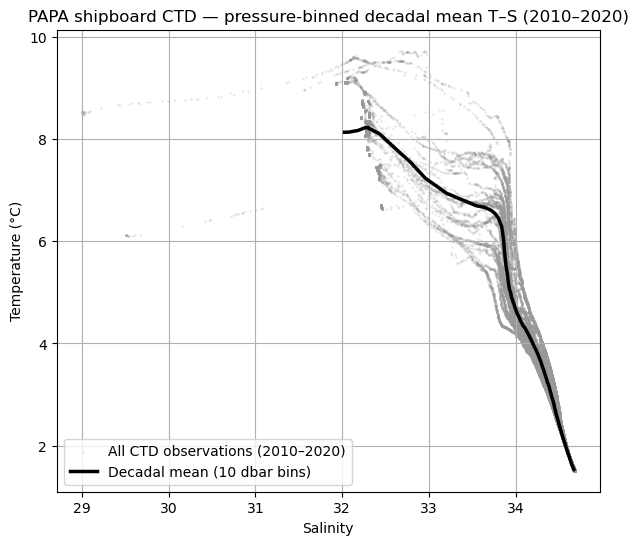

In [11]:
plt.figure(figsize=(7,6))

# Background envelope (optional but very useful)
plt.scatter(s, t, s=1, alpha=0.15, color="0.6",
            label="All CTD observations (2010–2020)")

# Decadal mean curve
plt.plot(s_mean, t_mean, color="black", linewidth=2.5,
         label="Decadal mean (10 dbar bins)")

plt.xlabel("Salinity")
plt.ylabel("Temperature (°C)")
plt.title("PAPA shipboard CTD — pressure-binned decadal mean T–S (2010–2020)")
plt.grid(True)
plt.legend()
plt.show()


## Add dbar z-variable as colourbar for better visual interpretation (max dbar 500m)

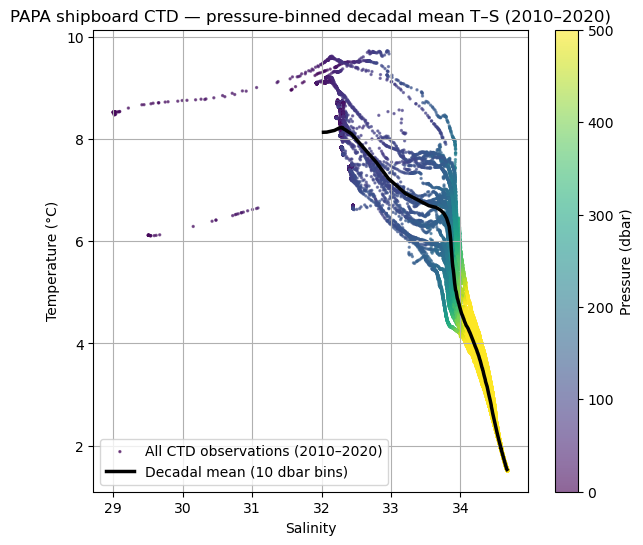

In [12]:
import matplotlib.colors as colors
plt.figure(figsize=(7,6))

sc = plt.scatter(
    s, t,
    c=p,
    s=2,
    cmap="viridis",
    alpha=0.6,
    norm=colors.Normalize(vmin=0, vmax=500),
    label="All CTD observations (2010–2020)"
)

plt.plot(
    s_mean, t_mean,
    color="black",
    linewidth=2.5,
    label="Decadal mean (10 dbar bins)"
)

plt.xlabel("Salinity")
plt.ylabel("Temperature (°C)")
plt.title("PAPA shipboard CTD — pressure-binned decadal mean T–S (2010–2020)")
plt.grid(True)

cb = plt.colorbar(sc)
cb.set_label("Pressure (dbar)")
#cb.set_ticks([0, 100, 200, 300, 400, 500])

plt.legend()
plt.show()


# SOTS TS Plot

In [13]:
# import SOTS files

data_dir = "/g/data/jk72/ob1561/Ship_data_PAPA/"  # same folder, as you said

all_files = sorted(glob.glob(data_dir + "/*ctd*.nc"))

sots_files = [f for f in all_files if (
    "096U20150321" in f or
    "09AR20071216" in f or
    "09AR20080322" in f or
    "09AR20110104" in f or
    "096U20180111" in f
)]

len(sots_files), sots_files

(7,
 ['/g/data/jk72/ob1561/Ship_data_PAPA/096U20150321_00005_00001_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/096U20150321_00007_00001_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/096U20150321_00009_00001_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/096U20180111_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/09AR20071216_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/09AR20080322_ctd.nc',
  '/g/data/jk72/ob1561/Ship_data_PAPA/09AR20110104_ctd.nc'])

In [14]:
# inspect files

ds = xr.open_dataset(sots_files[0])
list(ds.data_vars), list(ds.coords), dict(ds.dims)

/jobfs/159341261.gadi-pbs/ipykernel_559289/1558529840.py:4: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  list(ds.data_vars), list(ds.coords), dict(ds.dims)


(['pressure_QC',
  'temperature',
  'temperature_QC',
  'salinity',
  'salinity_QC',
  'oxygen',
  'oxygen_QC',
  'transmissometer',
  'transmissometer_QC',
  'PAR',
  'PAR_QC',
  'FLUOR',
  'FLUOR_QC',
  'woce_date',
  'woce_time',
  'station',
  'cast'],
 ['pressure', 'time', 'latitude', 'longitude'],
 {'pressure': 2249, 'time': 1, 'latitude': 1, 'longitude': 1})

In [19]:
# SOTS box
lat_min, lat_max = -48.0, -46.0
lon_min, lon_max = 141.0, 143.0

def first_existing(ds, names):
    for n in names:
        if n in ds.variables:
            return n
    return None

t_all, s_all, p_all = [], [], []
included_files = 0
skipped_outside_box = 0
skipped_missing_vars = []

for f in sots_files:
    ds = xr.open_dataset(f)

    # --- Pick variable names (supports both conventions)
    p_name = first_existing(ds, ["pressure", "CTDPRS", "ctd_pressure"])
    t_name = first_existing(ds, ["temperature", "temperature_0C", "ctd_temperature", "CTDTMP"])
    s_name = first_existing(ds, ["salinity", "ctd_salinity", "CTDSAL"])

    pqc_name = first_existing(ds, ["pressure_qc", "ctd_pressure_qc", "CTDPRS_QC"])
    tqc_name = first_existing(ds, ["temperature_qc", "ctd_temperature_qc", "CTDTMP_QC"])
    sqc_name = first_existing(ds, ["salinity_qc", "ctd_salinity_qc", "CTDSAL_QC"])

    lat_name = first_existing(ds, ["latitude", "lat", "LATITUDE"])
    lon_name = first_existing(ds, ["longitude", "lon", "LONGITUDE"])

    if any(v is None for v in [p_name, t_name, s_name, lat_name, lon_name]):
        skipped_missing_vars.append((f, p_name, t_name, s_name, lat_name, lon_name))
        continue

    # --- Cast-level lat/lon (robust scalar extraction)
    lat = ds[lat_name].values
    lon = ds[lon_name].values
    lat = float(np.asarray(lat).reshape(-1)[0])
    lon = float(np.asarray(lon).reshape(-1)[0])

    in_box = (lat_min <= lat <= lat_max) and (lon_min <= lon <= lon_max)
    if not in_box:
        skipped_outside_box += 1
        continue

    # --- Load arrays
    P = ds[p_name].astype("float64").values.ravel()
    T = ds[t_name].astype("float64").values.ravel()
    S = ds[s_name].astype("float64").values.ravel()

    # --- QC mask (if present). Accept flags 1 or 2.
    good = np.ones_like(P, dtype=bool)
    if pqc_name is not None:
        good &= np.isin(ds[pqc_name].values.ravel(), [1, 2])
    if tqc_name is not None:
        good &= np.isin(ds[tqc_name].values.ravel(), [1, 2])
    if sqc_name is not None:
        good &= np.isin(ds[sqc_name].values.ravel(), [1, 2])

    m = np.isfinite(P) & np.isfinite(T) & np.isfinite(S) & good
    if np.any(m):
        p_all.append(P[m])
        t_all.append(T[m])
        s_all.append(S[m])
        included_files += 1

# Concatenate pooled points
p = np.concatenate(p_all) if p_all else np.array([])
t = np.concatenate(t_all) if t_all else np.array([])
s = np.concatenate(s_all) if s_all else np.array([])

print("Files total:", len(sots_files))
print("Included (inside SOTS box):", included_files)
print("Skipped (outside SOTS box):", skipped_outside_box)
print("Skipped (missing core vars):", len(skipped_missing_vars))
print("Total pooled points:", t.size)

Files total: 7
Included (inside SOTS box): 2
Skipped (outside SOTS box): 5
Skipped (missing core vars): 0
Total pooled points: 4513


In [22]:
# bin pressure to 10dbar
bin_width = 10.0
p_bins = np.arange(0, np.nanmax(p) + bin_width, bin_width)
bin_index = np.digitize(p, p_bins)

p_mid, t_mean, s_mean = [], [], []

for i in range(1, len(p_bins)):
    m = bin_index == i
    if np.sum(m) >= 10:
        p_mid.append(np.nanmean(p[m]))
        t_mean.append(np.nanmean(t[m]))
        s_mean.append(np.nanmean(s[m]))

p_mid = np.array(p_mid)
t_mean = np.array(t_mean)
s_mean = np.array(s_mean)

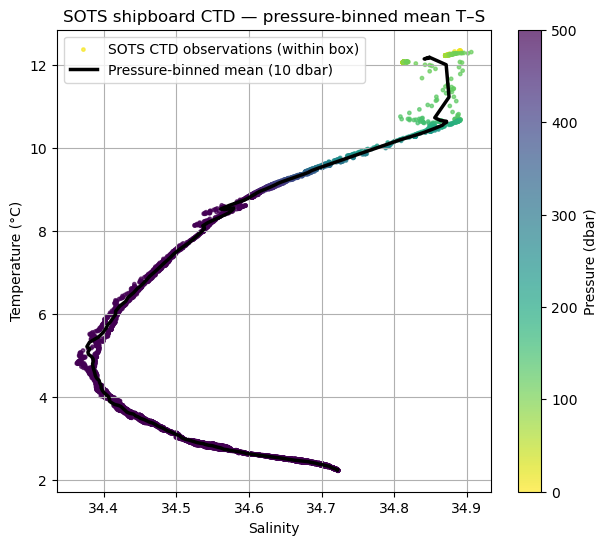

In [26]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    s, t,
    c=p,
    s=6,
    cmap="viridis_r",
    alpha=0.7,
    vmin=0,
    vmax=500,
    label="SOTS CTD observations (within box)"
)

plt.plot(
    s_mean, t_mean,
    color="black",
    linewidth=2.5,
    label="Pressure-binned mean (10 dbar)"
)

plt.xlabel("Salinity")
plt.ylabel("Temperature (°C)")
plt.title("SOTS shipboard CTD — pressure-binned mean T–S")
plt.grid(True)

cb = plt.colorbar(sc)
cb.set_label("Pressure (dbar)")

plt.legend()
plt.show()